# 🎓 Deepfake Detection - Skripsi
### Comparative Analysis: Spatio-Temporal vs Frequency Domain
---
## 📋 PANDUAN PENGGUNAAN (BACA DULU!)

**Script ini dibuat modular agar bisa dipakai oleh semua anggota tim.**

### Yang perlu kamu ubah (hanya di Cell KONFIGURASI):
1. **`MODEL_NAME`** → Pilih model yang kamu kerjakan
2. **`TRAINING_PHASE`** → Pilih fase training (1 atau 2)
3. **`ZIP_PATH`** → Sesuaikan path zip dataset di Google Drive kamu

### Daftar Model yang Tersedia:
| Kategori | Model Name | Keterangan |
|---|---|---|
| Spatio-Temporal | `r2plus1d` | Pseudo 3D / Decomposed 3D CNN (R(2+1)D-18) |
| Spatio-Temporal | `3dcnn_vit` | 3D-CNN + Vision Transformer |
| Spatio-Temporal | `efficientnet_bilstm` | EfficientNetV2 + BiLSTM |
| Frequency | `freqnet` | FreqNet |
| Frequency | `f3net` | F3Net |
| Frequency | `spsl` | SPSL (Spatial Phase Shallow Learning) |

### Fase Training:
- **Fase 1**: Train BlendFace FF → Test di BlendFace FF, BlendFace CDF, SimSwap CDF, HeyGen, Wav2Lip CDF
- **Fase 2**: Train BlendFace FF + Wav2Lip FF → Test di semua dataset yang sama

---

## CELL 1: Mount Google Drive & Unzip Dataset

In [ ]:
# ============================================================
# CELL 1: MOUNT DRIVE & EXTRACT DATASET
# Jalankan cell ini sekali saja di awal
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

# ⚠️  UBAH PATH INI sesuai lokasi zip kamu di Google Drive
ZIP_PATH = '/content/drive/MyDrive/DF40 zip/skripsi_deepfake_fast.zip'
EXTRACT_TO = '/content/'

# Cek apakah sudah di-extract sebelumnya (hemat waktu)
if not os.path.exists('/content/deepfakes_detection_datasets'):
    print('📦 Mengekstrak dataset...')
    os.makedirs(EXTRACT_TO, exist_ok=True)
    !unzip -q "{ZIP_PATH}" -d "{EXTRACT_TO}"
    print('✅ Berhasil diekstrak!')
else:
    print('✅ Dataset sudah ada, skip ekstraksi.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 Mengekstrak /content/drive/MyDrive/DF40 zip/skripsi_deepfake_fast.zip...
🔍 Mengecek integritas zip...
✅ Berhasil diekstrak!


## CELL 2: Install Library yang Dibutuhkan

In [3]:
# ============================================================
# CELL 2: INSTALL DEPENDENCIES
# Jalankan sekali saja
# ============================================================

print('📦 Menginstall dependencies...')
!pip install -q timm einops scikit-learn
print('✅ Selesai!')

📦 Menginstall dependencies...
✅ Selesai!


## CELL 3: ⚙️ KONFIGURASI UTAMA — UBAH DI SINI!

In [2]:
# ============================================================
# CELL 3: KONFIGURASI — INI YANG PERLU KAMU UBAH!
# ============================================================

# -------------------------------------------
# 🔧 PILIH MODEL (ubah sesuai tugasmu)
# -------------------------------------------
# Pilihan: 'r2plus1d', '3dcnn_vit', 'efficientnet_bilstm'
#           'freqnet', 'f3net', 'spsl'
MODEL_NAME = 'r2plus1d'   # ← UBAH INI

# -------------------------------------------
# 🔧 PILIH FASE TRAINING
# -------------------------------------------
# 1 = Train BlendFace saja
# 2 = Train BlendFace + Wav2Lip
TRAINING_PHASE = 2        # ← UBAH INI (1 atau 2)

# -------------------------------------------
# 🔧 PATH — Sesuaikan jika berbeda
# -------------------------------------------
IMAGE_ROOT    = '/content/deepfakes_detection_datasets'
JSON_DIR      = '/content/dataset_json_update'
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints_skripsi'  # Simpan ke Drive biar aman

# -------------------------------------------
# 🔧 HYPERPARAMETER — Bisa diubah jika perlu
# -------------------------------------------
NUM_FRAMES    = 16     # Jumlah frame per video (untuk model video)
IMAGE_SIZE    = 256    # Ukuran gambar (224 or 256)
BATCH_SIZE    = 16     # Perkecil jika OOM (Out Of Memory)
NUM_EPOCHS    = 15     # Jumlah epoch training
LEARNING_RATE = 2e-4   # Learning rate
ACCUMULATION_STEPS = 2 # Gradient accumulation (efektif batch = BATCH_SIZE * ini)
NUM_WORKERS   = 2      # DataLoader workers
SEED          = 42

# -------------------------------------------
# INFO OTOMATIS — Tidak perlu diubah
# -------------------------------------------
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Menentukan apakah model butuh input video (T,C,H,W) atau image (C,H,W)
VIDEO_MODELS  = ['r2plus1d', '3dcnn_vit', 'efficientnet_bilstm']
IMAGE_MODELS  = ['freqnet', 'f3net', 'spsl']
IS_VIDEO_MODEL = MODEL_NAME in VIDEO_MODELS
USE_FREQUENCY = MODEL_NAME in IMAGE_MODELS

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print('=' * 50)
print(f'🤖 Model       : {MODEL_NAME}')
print(f'📚 Fase        : {TRAINING_PHASE}')
print(f'💻 Device      : {device}')
print(f'🎬 Tipe input  : {"Video" if IS_VIDEO_MODEL else "Image"}')
print(f'📦 Batch size  : {BATCH_SIZE} (efektif: {BATCH_SIZE * ACCUMULATION_STEPS})')
print('=' * 50)

🤖 Model       : r2plus1d
📚 Fase        : 2
💻 Device      : cuda
🎬 Tipe input  : Video
📦 Batch size  : 16 (efektif: 32)


## CELL 4: Dataset Loader (Universal untuk Semua Model)

In [8]:
# ============================================================
# CELL 4: DATASET LOADER
# Otomatis handle video model vs image model
# ============================================================

import json
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

class DF40Dataset(Dataset):
    """
    Dataset universal untuk DF40.
    Mendukung semua kombinasi domain + method dari JSON.
    Otomatis return video (T,C,H,W) atau image (C,H,W) sesuai kebutuhan model.
    """

    def __init__(
        self,
        json_dir,
        image_root,
        configs,          # List of dict: [{'domain': 'ff', 'method': 'blendface', 'split': 'train'}, ...]
        is_video=True,    # True untuk spatio-temporal, False untuk frequency
        num_frames=32,
        image_size=224,
        transform=None,
        use_frequency=False  # True untuk model frequency (menambahkan FFT channel)
    ):
        self.samples = []
        self.num_frames = num_frames
        self.is_video = is_video
        self.image_root = image_root
        self.use_frequency = use_frequency
        self.image_size = image_size

        self.transform = transform if transform else T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
        if not json_files:
            raise FileNotFoundError(f'Tidak ada file JSON di: {json_dir}')

        total_loaded = 0
        for cfg in configs:
            domain_filter = cfg['domain'].lower()
            method_filter = cfg['method'].lower()
            split         = cfg['split']
            count = 0

            for j_file in json_files:
                with open(os.path.join(json_dir, j_file), 'r') as f:
                    content = json.load(f)

                for method_domain_key, classes in content.items():
                    key_lower = method_domain_key.lower()

                    # Filter: harus match domain DAN method
                    if domain_filter != 'none':
                        if domain_filter not in key_lower:
                            continue
                    if method_filter not in key_lower:
                        continue

                    for class_name, splits_data in classes.items():
                        if split not in splits_data:
                            continue
                        label = 0 if 'real' in class_name.lower() else 1

                        for vid_id, meta in splits_data[split].items():
                            paths = []
                            for p in meta.get('frames', []):
                                clean = p.replace('deepfakes_detection_datasets/', '')
                                if 'id' in clean.lower() and domain_filter == 'cdf':
                                    clean = clean.replace('FaceForensics++', 'Celeb-DF-v2/Celeb-real')
                                paths.append(os.path.join(self.image_root, clean))

                            valid_paths = [p for p in paths if os.path.exists(p)]
                            if len(valid_paths) > 0:
                                self.samples.append({
                                    'frames': valid_paths,
                                    'label': label,
                                    'method': method_filter,
                                    'domain': domain_filter
                                })
                                count += 1

            print(f'  ✅ [{domain_filter} - {method_filter} - {split}]: {count} samples')
            total_loaded += count

        print(f'  📊 Total: {total_loaded} samples dimuat')

        if total_loaded == 0:
            print('⚠️  WARNING: Tidak ada sample yang dimuat! Cek path dan nama method/domain.')

    def __len__(self):
        return len(self.samples)

    def _load_frame(self, path):
        """Load satu frame gambar dengan validasi."""

        # Layer 1: Cek file exist sebelum dibuka
        if not os.path.exists(path):
            raise FileNotFoundError(f'Frame tidak ditemukan: {path}')

        # Layer 2: Cek ukuran file (file corrupt biasanya 0 bytes)
        if os.path.getsize(path) == 0:
            raise ValueError(f'File corrupt (0 bytes): {path}')

        # Layer 3: Load dengan validasi
        img = Image.open(path).convert('RGB')

        # Layer 4: Pastikan gambar valid dan tidak rusak
        img.verify()               # Cek header file
        img = Image.open(path).convert('RGB')  # Buka ulang setelah verify (verify menutup file)

        # Layer 5: Cek dimensi masuk akal
        w, h = img.size
        if w < 10 or h < 10:
            raise ValueError(f'Gambar terlalu kecil ({w}x{h}): {path}')

        return self.transform(img)

    def __getitem__(self, idx):
        item = self.samples[idx]
        paths = item['frames']
        label = item['label']

        if self.is_video:
            # === VIDEO MODEL: return (C, T, H, W) ===
            indices = np.linspace(0, len(paths) - 1, self.num_frames, dtype=int)
            frames = []
            failed = []

            for i in indices:
                try:
                    frames.append(self._load_frame(paths[i]))
                except Exception as e:
                    failed.append((i, str(e)))

            # Jika lebih dari 50% frame gagal → skip sample ini
            if len(failed) > self.num_frames * 0.5:
                raise RuntimeError(
                    f'Sample {idx} gagal load {len(failed)}/{self.num_frames} frames.\n'
                    f'Contoh error: {failed[0][1]}'
                )

            # Jika sebagian kecil gagal → interpolasi dari frame terdekat
            if failed:
                print(f'⚠️  Sample {idx}: {len(failed)} frame diganti interpolasi')
                # Isi frame yang gagal dengan frame sebelumnya (forward fill)
                for pos in range(len(frames)):
                    if frames[pos] is None:
                        frames[pos] = frames[pos - 1] if pos > 0 else frames[pos + 1]
            # Stack → (T, C, H, W) → permute → (C, T, H, W)
            video = torch.stack(frames, dim=0).permute(1, 0, 2, 3)
            return video, label
        else:
            # === IMAGE MODEL: ambil 1 frame tengah ===
            mid_idx = len(paths) // 2
            frame = self._load_frame(paths[mid_idx])

            if self.use_frequency:
                # Tambah FFT magnitude spectrum sebagai extra feature
                freq = self._get_frequency_map(frame)
                frame = torch.cat([frame, freq], dim=0)  # (6, H, W)

            return frame, label

    def _get_frequency_map(self, tensor):
        """Hitung FFT magnitude map dari gambar (untuk model frequency)."""
        # tensor: (3, H, W)
        freq_maps = []
        for c in range(3):
            ch = tensor[c].numpy()
            f = np.fft.fft2(ch)
            fshift = np.fft.fftshift(f)
            magnitude = np.log1p(np.abs(fshift)).astype(np.float32)
            # Normalize
            magnitude = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)
            freq_maps.append(torch.tensor(magnitude).unsqueeze(0))
        return torch.cat(freq_maps, dim=0)  # (3, H, W)


def get_transforms(image_size=224, augment=True):
    """Transform untuk training (dengan augmentasi) dan validasi/testing."""
    train_transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    val_transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return train_transform, val_transform


print('✅ Dataset class berhasil didefinisikan.')

✅ Dataset class berhasil didefinisikan.


## CELL 5: Definisi Semua Model

In [ ]:
# ============================================================
# CELL 5: DEFINISI SEMUA MODEL
# Setiap anggota tim mengerjakan model yang berbeda.
# Class template sudah disediakan untuk semua 6 model.
# ============================================================

import torch
import torch.nn as nn
import torchvision.models.video as video_models
import torchvision.models as models
import timm


# ==================================================
# ── SPATIO-TEMPORAL MODEL 1: Pseudo 3D / Decomposed 3D CNN (R(2+1)D-18)
# ==================================================
class R2Plus1D_Detector(nn.Module):
    """
    R(2+1)D-18: Decomposed Spatiotemporal Convolution.
    Spatial (2D) dan Temporal (1D) diproses terpisah,
    lebih efisien dan akurat dari pure 3D CNN (R3D-18).

    Paper: Tran et al., CVPR 2018
    Input: (B, C, T, H, W)
    """
    def __init__(self):
        super().__init__()
        self.backbone = video_models.r2plus1d_18(
            weights=video_models.R2Plus1D_18_Weights.KINETICS400_V1
        )
        in_features = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x)  # (B, 1)

# ==================================================
# ── SPATIO-TEMPORAL MODEL 2: 3D-CNN + ViT
# ==================================================
class CNN3D_ViT_Detector(nn.Module):
    """3D-CNN untuk ekstrak fitur spatio-temporal,
    lalu ViT encoder untuk global attention.
    Input: (B, C, T, H, W)

    📝 CATATAN UNTUK PENGEMBANG MODEL INI:
    Arsitektur ini adalah template. Kamu bisa:
    - Mengganti ukuran hidden dim
    - Menambah layer transformer
    - Menggunakan pretrained ViT dari timm
    """
    def __init__(self, num_frames=16, embed_dim=512, num_heads=8, num_layers=4):
        super().__init__()

        # 3D-CNN backbone (ekstrak spatio-temporal features)
        base = video_models.r3d_18(weights=video_models.R3D_18_Weights.DEFAULT)
        # Ambil semua layer kecuali FC dan avgpool
        self.cnn3d = nn.Sequential(
            base.stem,
            base.layer1,
            base.layer2,
            base.layer3,
            base.layer4
        )
        self.gap = nn.AdaptiveAvgPool3d((num_frames // 4, 1, 1))  # (B, 512, T', 1, 1)

        # Projection ke embed_dim
        self.proj = nn.Linear(512, embed_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Classifier
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, x):
        B = x.size(0)
        # 3D-CNN feature extraction
        feat = self.cnn3d(x)              # (B, 512, T', H', W')
        feat = self.gap(feat)             # (B, 512, T', 1, 1)
        feat = feat.squeeze(-1).squeeze(-1)  # (B, 512, T')
        feat = feat.permute(0, 2, 1)      # (B, T', 512)
        feat = self.proj(feat)            # (B, T', embed_dim)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        feat = torch.cat([cls, feat], dim=1)    # (B, T'+1, embed_dim)

        # Transformer
        out = self.transformer(feat)      # (B, T'+1, embed_dim)
        cls_out = out[:, 0]               # Ambil CLS token

        return self.classifier(cls_out)   # (B, 1)


# ==================================================
# ── SPATIO-TEMPORAL MODEL 3: EfficientNetV2 + BiLSTM
# ==================================================
class EfficientNetBiLSTM_Detector(nn.Module):
    """EfficientNetV2 sebagai frame-level feature extractor,
    BiLSTM untuk modeling temporal sequence.
    Input: (B, C, T, H, W)

    📝 CATATAN UNTUK PENGEMBANG MODEL INI:
    - hidden_size bisa diubah (default 512)
    - num_layers LSTM bisa diubah
    - Bisa dicoba ganti EfficientNetV2 dengan EfficientNetV2-M/L
    """
    def __init__(self, num_frames=16, hidden_size=512, num_lstm_layers=2):
        super().__init__()

        # EfficientNetV2-S sebagai frame encoder
        efficientnet = timm.create_model('tf_efficientnetv2_s', pretrained=True)
        self.frame_encoder = nn.Sequential(*list(efficientnet.children())[:-1])  # Hapus head
        self.frame_pool = nn.AdaptiveAvgPool2d(1)

        # Cari dimensi output EfficientNetV2-S
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224)
            feat = self.frame_encoder(dummy)
            if feat.dim() == 4:
                feat = self.frame_pool(feat).squeeze(-1).squeeze(-1)
            frame_feat_dim = feat.shape[-1]

        print(f'  EfficientNet feature dim: {frame_feat_dim}')

        # Bidirectional LSTM
        self.bilstm = nn.LSTM(
            input_size=frame_feat_dim,
            hidden_size=hidden_size,
            num_layers=num_lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if num_lstm_layers > 1 else 0
        )

        # Classifier (bidirectional → 2 * hidden_size)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        # x: (B, C, T, H, W)
        B, C, T, H, W = x.shape

        # Proses tiap frame
        x = x.permute(0, 2, 1, 3, 4)          # (B, T, C, H, W)
        x = x.reshape(B * T, C, H, W)          # (B*T, C, H, W)
        feat = self.frame_encoder(x)            # (B*T, D, h, w)
        if feat.dim() == 4:
            feat = self.frame_pool(feat).squeeze(-1).squeeze(-1)  # (B*T, D)
        feat = feat.reshape(B, T, -1)           # (B, T, D)

        # BiLSTM
        lstm_out, _ = self.bilstm(feat)         # (B, T, 2*hidden)
        pooled = lstm_out.mean(dim=1)           # Mean pooling across time

        return self.classifier(pooled)          # (B, 1)


# ==================================================
# ── FREQUENCY MODEL 1: FreqNet
# ==================================================
class FreqNet_Detector(nn.Module):
    """FreqNet: Deteksi berbasis frequency domain.
    Menggunakan ResNet backbone dengan input frequency maps.
    Input: (B, C, H, W) — C=3 RGB atau C=6 dengan freq map

    📝 CATATAN UNTUK PENGEMBANG MODEL INI:
    Referensi: FreqNet menggunakan multi-scale frequency analysis.
    Kamu bisa mengembangkan arsitektur ini lebih lanjut.
    """
    def __init__(self, in_channels=3):
        super().__init__()

        # Frequency feature extractor (DCT-based preprocessing)
        self.freq_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # Backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        resnet.conv1 = nn.Conv2d(64, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        freq = self.freq_conv(x)
        feat = self.backbone(freq)
        feat = self.gap(feat).squeeze(-1).squeeze(-1)
        return self.classifier(feat)


# ==================================================
# ── FREQUENCY MODEL 2: F3Net
# ==================================================
class F3Net_Detector(nn.Module):
    """F3Net: Frequency, Fusion, Fine-grained Network.
    Menggunakan dual-stream: RGB + Frequency, lalu fusion.
    Input: (B, 3, H, W)

    📝 CATATAN UNTUK PENGEMBANG MODEL INI:
    Referensi paper: F3Net (AAAI 2021)
    Arsitektur ini adalah interpretasi template.
    Kamu bisa menambah cross-attention antar stream.
    """
    def __init__(self):
        super().__init__()

        # RGB Stream
        resnet_rgb = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.rgb_stream = nn.Sequential(
            resnet_rgb.conv1, resnet_rgb.bn1, resnet_rgb.relu, resnet_rgb.maxpool,
            resnet_rgb.layer1, resnet_rgb.layer2, resnet_rgb.layer3, resnet_rgb.layer4
        )

        # Frequency Stream (input: FFT magnitude dari RGB)
        resnet_freq = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.freq_stream = nn.Sequential(
            resnet_freq.conv1, resnet_freq.bn1, resnet_freq.relu, resnet_freq.maxpool,
            resnet_freq.layer1, resnet_freq.layer2, resnet_freq.layer3, resnet_freq.layer4
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        # Fusion + Classifier
        self.fusion = nn.Sequential(
            nn.Linear(512 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def _get_freq(self, x):
        """Hitung FFT magnitude map real-time."""
        x_np = x.detach().cpu().numpy()
        freq_maps = []
        for b in range(x_np.shape[0]):
            ch_maps = []
            for c in range(3):
                f = np.fft.fft2(x_np[b, c])
                mag = np.log1p(np.abs(np.fft.fftshift(f))).astype(np.float32)
                mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
                ch_maps.append(mag)
            freq_maps.append(np.stack(ch_maps, axis=0))
        return torch.tensor(np.stack(freq_maps), device=x.device, dtype=x.dtype)

    def forward(self, x):
        freq_x = self._get_freq(x)

        rgb_feat  = self.gap(self.rgb_stream(x)).squeeze(-1).squeeze(-1)
        freq_feat = self.gap(self.freq_stream(freq_x)).squeeze(-1).squeeze(-1)

        combined = torch.cat([rgb_feat, freq_feat], dim=1)
        return self.fusion(combined)


# ==================================================
# ── FREQUENCY MODEL 3: SPSL
# ==================================================
class SPSL_Detector(nn.Module):
    """SPSL: Spatial-Phase Shallow Learning.
    Menggunakan phase spectrum dari FFT untuk deteksi upsampling artifacts.
    Input: (B, 3, H, W)

    📝 CATATAN UNTUK PENGEMBANG MODEL INI:
    Referensi paper: SPSL (CVPR 2021)
    SPSL menggunakan phase spectrum (bukan magnitude) sebagai kunci deteksi.
    """
    def __init__(self):
        super().__init__()

        # Input: 3 (RGB) + 3 (Phase Spectrum) = 6 channel
        xception_base = timm.create_model('xception', pretrained=True, num_classes=0)

        # Modifikasi input conv untuk 6 channel
        old_conv = xception_base.conv1
        new_conv = nn.Conv2d(6, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride,
                             padding=old_conv.padding, bias=False)
        # Copy pretrained weights untuk 3 channel pertama
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:] = old_conv.weight  # Duplikat untuk phase channels
        xception_base.conv1 = new_conv

        self.backbone = xception_base
        feat_dim = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(feat_dim, 1)
        )

    def _get_phase(self, x):
        """Hitung phase spectrum dari gambar."""
        x_np = x.detach().cpu().numpy()
        phase_maps = []
        for b in range(x_np.shape[0]):
            ch_maps = []
            for c in range(3):
                f = np.fft.fft2(x_np[b, c])
                phase = np.angle(f).astype(np.float32)
                phase = (phase + np.pi) / (2 * np.pi)  # Normalize ke [0, 1]
                ch_maps.append(phase)
            phase_maps.append(np.stack(ch_maps, axis=0))
        return torch.tensor(np.stack(phase_maps), device=x.device, dtype=x.dtype)

    def forward(self, x):
        phase = self._get_phase(x)
        x_combined = torch.cat([x, phase], dim=1)  # (B, 6, H, W)
        feat = self.backbone(x_combined)
        return self.classifier(feat)


# ==================================================
# ── FACTORY FUNCTION: Panggil model dengan nama
# ==================================================
def get_model(model_name, num_frames=16):
    """Factory function untuk load model berdasarkan nama string."""
    model_map = {
        'r2plus1d':             R2Plus1D_Detector,
        '3dcnn_vit':            CNN3D_ViT_Detector,
        'efficientnet_bilstm':  EfficientNetBiLSTM_Detector,
        'freqnet':              FreqNet_Detector,
        'f3net':                F3Net_Detector,
        'spsl':                 SPSL_Detector,
    }
    if model_name not in model_map:
        raise ValueError(f'Model "{model_name}" tidak dikenal. Pilih dari: {list(model_map.keys())}')

    if model_name in ['3dcnn_vit', 'efficientnet_bilstm']:
        model = model_map[model_name](num_frames=num_frames)
    else:
        model = model_map[model_name]()

    return model


print('✅ Semua model berhasil didefinisikan.')

✅ Semua model berhasil didefinisikan.


## CELL 6: Setup Dataset & DataLoader

In [ ]:
# ============================================================
# CELL 6: SETUP DATASET
# Fase 1 & 2 sudah didefinisikan, pilih berdasarkan TRAINING_PHASE
# ============================================================

torch.manual_seed(SEED)
train_transform, val_transform = get_transforms(IMAGE_SIZE, augment=True)

# ─── Konfigurasi Training per Fase ───────────────────────────
PHASE_CONFIGS = {
    1: {
        'train': [
            {'domain': 'ff', 'method': 'blendface', 'split': 'train'}
        ],
        'test': [
            {'domain': 'ff',   'method': 'blendface',   'split': 'test',  'name': 'BlendFace-FF'},
            {'domain': 'cdf',  'method': 'blendface',   'split': 'test',  'name': 'BlendFace-CDF'},
            {'domain': 'ff',   'method': 'wav2lip',     'split': 'test',  'name': 'Wav2Lip-FF'},
            {'domain': 'cdf',  'method': 'wav2lip',     'split': 'test',  'name': 'Wav2Lip-CDF'},
            {'domain': 'ff',   'method': 'lia',         'split': 'test',  'name': 'Lia-FF'},
            {'domain': 'cdf',  'method': 'mcnet',       'split': 'test',  'name': 'MCNet-CDF'},
            {'domain': 'ff',   'method': 'uniface',     'split': 'test',  'name': 'Uniface-FF'},
            {'domain': 'cdf',  'method': 'simswap',     'split': 'test',  'name': 'SimSwap-CDF'},
            {'domain': 'none', 'method': 'heygen',      'split': 'test',  'name': 'HeyGen'},
            {'domain': 'none', 'method': 'deepfacelab', 'split': 'test',  'name': 'DeepFaceLab'},
        ]
    },
    2: {
        'train': [
            {'domain': 'ff', 'method': 'blendface',    'split': 'train'},
            # {'domain': 'ff', 'method': 'inswap',       'split': 'train'},
            # {'domain': 'ff', 'method': 'hyperreenact', 'split': 'train'},
            {'domain': 'ff', 'method': 'wav2lip',      'split': 'train'}
        ],
        'test': [
            {'domain': 'ff',   'method': 'blendface',   'split': 'test',  'name': 'BlendFace-FF'},
            {'domain': 'cdf',  'method': 'blendface',   'split': 'test',  'name': 'BlendFace-CDF'},
            {'domain': 'ff',   'method': 'wav2lip',     'split': 'test',  'name': 'Wav2Lip-FF'},
            {'domain': 'cdf',  'method': 'wav2lip',     'split': 'test',  'name': 'Wav2Lip-CDF'},
            {'domain': 'ff',   'method': 'lia',         'split': 'test',  'name': 'Lia-FF'},
            {'domain': 'cdf',  'method': 'mcnet',       'split': 'test',  'name': 'MCNet-CDF'},
            {'domain': 'ff',   'method': 'uniface',     'split': 'test',  'name': 'Uniface-FF'},
            {'domain': 'cdf',  'method': 'simswap',     'split': 'test',  'name': 'SimSwap-CDF'},
            {'domain': 'none', 'method': 'heygen',      'split': 'test',  'name': 'HeyGen'},
            {'domain': 'none', 'method': 'deepfacelab', 'split': 'test',  'name': 'DeepFaceLab'},
        ]
    }
}

phase_cfg = PHASE_CONFIGS[TRAINING_PHASE]

# ─── Build Training Dataset ──────────────────────────────────
print(f'\n📦 Memuat dataset TRAINING (Fase {TRAINING_PHASE})...')
full_train_dataset = DF40Dataset(
    json_dir=JSON_DIR,
    image_root=IMAGE_ROOT,
    configs=phase_cfg['train'],
    is_video=IS_VIDEO_MODEL,
    num_frames=NUM_FRAMES,
    image_size=IMAGE_SIZE,
    transform=train_transform,
    use_frequency=USE_FREQUENCY
)

# Split 90% train, 10% internal val
train_size = int(0.9 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size
train_set, internal_val_set = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'  → Train: {len(train_set)} | Internal Val: {len(internal_val_set)}')

train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True, persistent_workers=True
)
val_loader = DataLoader(
    internal_val_set, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

# ─── Build Test Datasets ─────────────────────────────────────
print(f'\n📦 Memuat dataset TESTING...')
test_loaders = {}
for test_cfg in phase_cfg['test']:
    cfg_copy = [
        {'domain': test_cfg['domain'], 'method': test_cfg['method'], 'split': test_cfg['split']}
    ]
    try:
        ds = DF40Dataset(
            json_dir=JSON_DIR,
            image_root=IMAGE_ROOT,
            configs=cfg_copy,
            is_video=IS_VIDEO_MODEL,
            num_frames=NUM_FRAMES,
            image_size=IMAGE_SIZE,
            transform=val_transform,
            use_frequency=USE_FREQUENCY
        )
        if len(ds) > 0:
            test_loaders[test_cfg['name']] = DataLoader(
                ds, batch_size=BATCH_SIZE,
                shuffle=False, num_workers=NUM_WORKERS,
                pin_memory=True, persistent_workers=True
            )
            print(f'  ✅ {test_cfg["name"]}: {len(ds)} samples\n')
        else:
            print(f'  ⚠️  {test_cfg["name"]}: 0 samples — skip\n')
    except Exception as e:
        print(f'  ❌ {test_cfg["name"]}: Error — {e}\n')

print(f'\n✅ Total test sets tersedia: {len(test_loaders)}')


📦 Memuat dataset TRAINING (Fase 2)...
  ✅ [ff - blendface - train]: 1430 samples
  ✅ [ff - wav2lip - train]: 1434 samples
  📊 Total: 2864 samples dimuat
  → Train: 2577 | Internal Val: 287

📦 Memuat dataset TESTING...
  ✅ [ff - blendface - test]: 280 samples
  📊 Total: 280 samples dimuat
  ✅ BlendFace-FF: 280 samples

  ✅ [cdf - blendface - test]: 818 samples
  📊 Total: 818 samples dimuat
  ✅ BlendFace-CDF: 818 samples

  ✅ [ff - wav2lip - test]: 280 samples
  📊 Total: 280 samples dimuat
  ✅ Wav2Lip-FF: 280 samples

  ✅ [cdf - wav2lip - test]: 844 samples
  📊 Total: 844 samples dimuat
  ✅ Wav2Lip-CDF: 844 samples

  ✅ [ff - lia - test]: 280 samples
  📊 Total: 280 samples dimuat
  ✅ Lia-FF: 280 samples

  ✅ [cdf - mcnet - test]: 825 samples
  📊 Total: 825 samples dimuat
  ✅ MCNet-CDF: 825 samples

  ✅ [ff - uniface - test]: 280 samples
  📊 Total: 280 samples dimuat
  ✅ Uniface-FF: 280 samples

  ✅ [cdf - simswap - test]: 819 samples
  📊 Total: 819 samples dimuat
  ✅ SimSwap-CDF: 819 sa

In [ ]:
def validate_dataset(dataset, sample_size=100, name='Dataset'):
    """
    Cek sample acak dari dataset sebelum training.
    Deteksi file missing/corrupt lebih awal.
    """
    from tqdm.auto import tqdm
    import random
    import gc
    indices = random.sample(range(len(dataset)), min(sample_size, len(dataset)))

    errors = []
    for idx in tqdm(indices, desc=f'\nValidating {name}'):
        try:
            _ = dataset[idx]
        except Exception as e:
            errors.append((idx, str(e)))

    if errors:
        print(f'\n⚠️  {name}: {len(errors)}/{sample_size} sample bermasalah:')
        for idx, err in errors[:5]:  # Tampilkan 5 contoh
            print(f'   Sample {idx}: {err}')
    else:
        print(f'✅ {name}: {sample_size} sample dicek, semua OK')

    return len(errors) == 0


# Jalankan di Cell 6 setelah buat dataset:
print('\n🔍 Validasi dataset sebelum training...')
validate_dataset(train_set,        sample_size=50,  name='Train')
validate_dataset(internal_val_set, sample_size=20,  name='Val')
for name, loader in test_loaders.items():
    gc.collect()
    torch.cuda.empty_cache()
    validate_dataset(loader.dataset, sample_size=20, name=name)


🔍 Validasi dataset sebelum training...



Validating Train:   0%|          | 0/50 [00:00<?, ?it/s]

✅ Train: 50 sample dicek, semua OK



Validating Val:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Val: 20 sample dicek, semua OK


...

✅ SimSwap-CDF: 20 sample dicek, semua OK



Validating HeyGen:   0%|          | 0/20 [00:00<?, ?it/s]

✅ HeyGen: 20 sample dicek, semua OK



Validating DeepFaceLab:   0%|          | 0/20 [00:00<?, ?it/s]

✅ DeepFaceLab: 20 sample dicek, semua OK


## CELL 7: Initialize Model, Optimizer, Scheduler

In [ ]:
def get_optimizer(model, model_name, base_lr=1e-4):
    """
    Optimizer yang menyesuaikan diri dengan arsitektur model.
    Model dengan transformer pakai differential learning rate,
    model tanpa transformer pakai single learning rate biasa.
    """

    # Cek apakah model punya layer dengan nama 'transformer'
    transformer_params = [
        p for n, p in model.named_parameters() if 'transformer' in n
    ]
    non_transformer_params = [
        p for n, p in model.named_parameters() if 'transformer' not in n
    ]

    has_transformer = len(transformer_params) > 0

    if has_transformer:
        # Differential LR: transformer butuh LR lebih kecil
        # karena sudah pretrained dan sensitif terhadap update besar
        param_groups = [
            {'params': non_transformer_params, 'lr': base_lr},
            {'params': transformer_params,     'lr': base_lr * 0.5}
        ]
        print(f'  Optimizer: AdamW dengan differential LR')
        print(f'    Non-transformer params: lr={base_lr}')
        print(f'    Transformer params:     lr={base_lr * 0.5}')
    else:
        # Single LR untuk model tanpa transformer
        param_groups = [{'params': model.parameters(), 'lr': base_lr}]
        print(f'  Optimizer: AdamW dengan single LR={base_lr}')

    return torch.optim.AdamW(param_groups, weight_decay=1e-2)

In [10]:
# ============================================================
# CELL 7: INISIALISASI MODEL (FINE TUNING IMAGE SIZE 256)
# ============================================================

print(f'🤖 Menginisialisasi model: {MODEL_NAME}...')
model = get_model(MODEL_NAME, num_frames=NUM_FRAMES)
model = model.to(device)

# Hitung total parameter
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Total params: {total_params:,}')
print(f'  Trainable:    {trainable_params:,}')

# Loss function
criterion = nn.BCEWithLogitsLoss()

def freeze_backbone(model, model_name):
    for name, param in model.named_parameters():
        if model_name == 'r2plus1d' and 'fc' not in name:
            param.requires_grad = False
        elif model_name == 'efficientnet_bilstm' and 'frame_encoder' in name:
            param.requires_grad = False
        elif model_name in ['freqnet', 'f3net', 'spsl'] and 'classifier' not in name and 'fusion' not in name:
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [Stage 1] Trainable params (head only): {trainable:,}')

def unfreeze_last_layers(model, model_name):
    for name, param in model.named_parameters():
        if model_name == 'r2plus1d' and ('layer4' in name or 'fc' in name):
            param.requires_grad = True
        elif model_name == 'efficientnet_bilstm' and ('blocks.6' in name or 'bilstm' in name or 'classifier' in name):
            param.requires_grad = True
        elif model_name in ['freqnet', 'f3net', 'spsl'] and ('layer4' in name or 'classifier' in name or 'fusion' in name):
            param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [Stage 2] Trainable params (layer4 + head): {trainable:,}')

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  [Stage 3] Trainable params (all): {trainable:,}')

def get_optimizer_for_stage(model, stage, base_lr):
    if stage == 1:
        params = [p for p in model.parameters() if p.requires_grad]
        return torch.optim.Adam(params, lr=base_lr)
    elif stage == 2:
        head_keys = ['fc', 'classifier', 'fusion', 'bilstm']
        head_params = [p for n, p in model.named_parameters()
                       if p.requires_grad and any(k in n for k in head_keys)]
        backbone_params = [p for n, p in model.named_parameters()
                           if p.requires_grad and not any(k in n for k in head_keys)]
        return torch.optim.Adam([
            {'params': head_params,     'lr': base_lr},
            {'params': backbone_params, 'lr': base_lr * 0.1}
        ])
    elif stage == 3:
        return torch.optim.Adam(model.parameters(), lr=base_lr * 0.01)

# ── [BARU] Inisialisasi Stage 1 ─────────────────────────────
freeze_backbone(model, MODEL_NAME)
optimizer = get_optimizer_for_stage(model, stage=1, base_lr=LEARNING_RATE)

use_amp = device.type == 'cuda'
scaler  = torch.amp.GradScaler(device.type) if use_amp else None

print(f'  Mixed Precision: {use_amp}')
print('\n✅ Model siap! Mulai dari Stage 1 (head only).')

🤖 Menginisialisasi model: r2plus1d...
  Total params: 31,300,638
  Trainable:    31,300,638
  [Stage 1] Trainable params (head only): 513
  Mixed Precision: True

✅ Model siap! Mulai dari Stage 1 (head only).


## CELL 8: Training Loop

In [ ]:
# ============================================================
# CELL 8: TRAINING (FINE TUNING IMAGE SIZE 256)
# ============================================================

from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score


def evaluate(model, loader, device, desc='Evaluating'):
    """Evaluasi model: return accuracy dan AUC."""
    model.eval()
    all_labels, all_probs = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=desc, leave=False):
            inputs = inputs.to(device)
            labels = labels.float().to(device)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = model(inputs).squeeze(1)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    try:
        auc = roc_auc_score(all_labels, all_probs)
        auc = float(auc)
    except Exception:
        auc = 0.5  # Jika hanya 1 kelas

    acc = float(correct / total * 100)
    return acc, auc

STAGE_EPOCHS = {1: 5, 2: 10}  # Total = 15 epoch

history = {
    'train_loss': [], 'train_acc': [],
    'val_acc':    [], 'val_auc':   [],
    'stage':      []                   # [BARU] tracking stage untuk visualisasi
}
best_val_auc  = 0.0
epoch_counter = 0
checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    f'{MODEL_NAME}_phase{TRAINING_PHASE}_best.pth'
)

print(f'\n🚀 Training — {MODEL_NAME} | Fase {TRAINING_PHASE}')
print(f'   Stage 1 (epoch 1-5)  : Head only')
print(f'   Stage 2 (epoch 6-15) : Layer4 + Head')
# print(f'   Stage 3 (epoch 16-20): Full fine-tuning\n')

# ── [BARU] Loop per stage ────────────────────────────────────
for stage, n_epochs in STAGE_EPOCHS.items():

    # Transisi stage
    if stage == 2:
        print('\n🔓 Memasuki Stage 2: Unfreeze layer terakhir...')
        unfreeze_last_layers(model, MODEL_NAME)
        optimizer = get_optimizer_for_stage(model, stage=2, base_lr=LEARNING_RATE)
    elif stage == 3:
        print('\n🔓 Memasuki Stage 3: Unfreeze semua layer...')
        unfreeze_all(model)
        optimizer = get_optimizer_for_stage(model, stage=3, base_lr=LEARNING_RATE)

    # Scheduler reset tiap stage
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-6
    )

    for epoch in range(n_epochs):
        epoch_counter += 1

        # ── Train ─────────────────────────────────────────────
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0
        optimizer.zero_grad()

        pbar = tqdm(
            enumerate(train_loader), total=len(train_loader),
            desc=f'\nEpoch {epoch_counter:02d}/{NUM_EPOCHS} [Stage {stage}]'  # [UBAH] tambah stage
        )

        for step, (inputs, labels) in pbar:
            inputs = inputs.to(device)
            labels = labels.float().to(device)

            if use_amp:
                with torch.amp.autocast(device_type=device.type):
                    logits = model(inputs).squeeze(1)
                    loss   = criterion(logits, labels) / ACCUMULATION_STEPS
                scaler.scale(loss).backward()
            else:
                logits = model(inputs).squeeze(1)
                loss   = criterion(logits, labels) / ACCUMULATION_STEPS
                loss.backward()

            if (step + 1) % ACCUMULATION_STEPS == 0:
                if use_amp:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                optimizer.zero_grad()

            preds = (torch.sigmoid(logits) > 0.5).float()
            running_correct += (preds == labels).sum().item()
            running_total   += labels.size(0)
            running_loss    += loss.item() * ACCUMULATION_STEPS

            pbar.set_postfix({
                'loss': f'{running_loss / (step+1):.4f}',
                'acc':  f'{running_correct / running_total * 100:.1f}%'
            })

        scheduler.step()

        # ── Validation ────────────────────────────────────────
        val_acc, val_auc = evaluate(model, val_loader, device, desc='Val')

        train_loss = running_loss / len(train_loader)
        train_acc  = running_correct / running_total * 100

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        history['stage'].append(stage)              # [BARU]

        print(f'  Epoch {epoch_counter:02d} [S{stage}] | '
              f'Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.2f}% | '
              f'Val Acc: {val_acc:.2f}% | '
              f'Val AUC: {val_auc:.4f}')

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save({
                'epoch':           epoch_counter,
                'stage':           stage,            # [BARU]
                'model_state':     model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_auc':         float(val_auc),
                'history':         history,
                'stage_epochs':    STAGE_EPOCHS,
                'config': {
                    'model_name':    MODEL_NAME,
                    'phase':         TRAINING_PHASE,
                    'num_frames':    NUM_FRAMES,
                    'image_size':    IMAGE_SIZE
                }
            }, checkpoint_path)
            print(f'  💾 Checkpoint tersimpan! (Val AUC: {val_auc:.4f})')

print(f'\n✅ Training selesai! Best Val AUC: {best_val_auc:.4f}')


🚀 Training — r2plus1d | Fase 2
   Stage 1 (epoch 1-5)  : Head only
   Stage 2 (epoch 6-15) : Layer4 + Head



Epoch 01/15 [Stage 1]:   0%|          | 0/161 [00:00<?, ?it/s]

KeyboardInterrupt: 

## CELL 9: Visualisasi Training History

/tmp/ipykernel_36997/2594761028.py:61: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


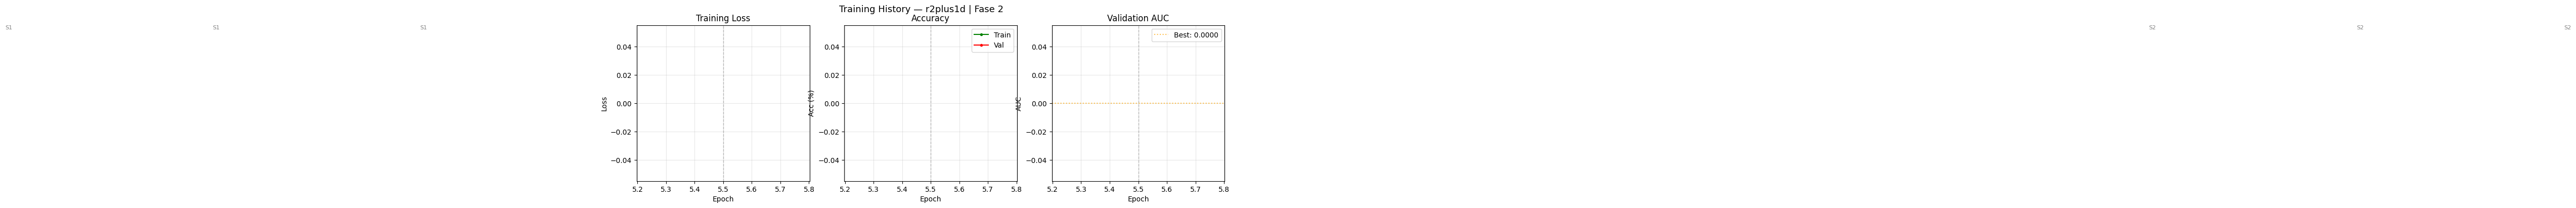

✅ Plot tersimpan di: /content/drive/MyDrive/checkpoints_skripsi/r2plus1d_phase2_history.png


In [ ]:
# ============================================================
# CELL 9: VISUALISASI HISTORY (FINE TUNING IMAGE SIZE 256)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Training History — {MODEL_NAME} | Fase {TRAINING_PHASE}', fontsize=13)

epochs = range(1, len(history['train_loss']) + 1)

# [BARU] Hitung batas antar stage untuk garis vertikal
stage_boundaries = []
cumulative = 0
for stage, n_ep in STAGE_EPOCHS.items():
    cumulative += n_ep
    if cumulative < NUM_EPOCHS:
        stage_boundaries.append(cumulative + 0.5)

def add_stage_lines(ax):
    """Tambah garis vertikal pemisah stage."""
    for boundary in stage_boundaries:
        ax.axvline(x=boundary, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    # Label stage
    prev = 0
    for i, (stage, n_ep) in enumerate(STAGE_EPOCHS.items()):
        mid = prev + n_ep / 2
        ax.text(mid + 0.5, ax.get_ylim()[1] * 0.95,
                f'S{stage}', fontsize=8, color='gray', ha='center')
        prev += n_ep

# Plot 1: Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
add_stage_lines(axes[0])

# Plot 2: Accuracy
axes[1].plot(epochs, history['train_acc'], 'g-o', label='Train', markersize=3)
axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val',   markersize=3)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acc (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
add_stage_lines(axes[1])

# Plot 3: AUC
axes[2].plot(epochs, history['val_auc'], 'm-o', markersize=3)
axes[2].axhline(y=best_val_auc, color='orange', linestyle=':', alpha=0.7, label=f'Best: {best_val_auc:.4f}')          # [BARU]
axes[2].set_title('Validation AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
add_stage_lines(axes[2])

plt.tight_layout()
save_path = os.path.join(
    CHECKPOINT_DIR,
    f'{MODEL_NAME}_phase{TRAINING_PHASE}_history.png'
)
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot tersimpan di: {save_path}')

## CELL 10: 🧪 Testing pada Semua Dataset

In [ ]:
# ============================================================
# CELL 10: TESTING
# Load checkpoint terbaik, test di semua test sets
# ============================================================

import gc

print('🔄 Load checkpoint terbaik...')
ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'  Epoch terbaik: {ckpt["epoch"]} | Val AUC: {ckpt["val_auc"]:.4f}')

print(f'\n🧪 Testing pada semua test sets...')
print('-' * 55)
print(f'{"Dataset":<20} {"Acc (%)":>10} {"AUC":>10}')
print('-' * 55)

results = {}
for name, loader in test_loaders.items():
    gc.collect()
    torch.cuda.empty_cache()
    acc, auc = evaluate(model, loader, device, desc=f'Test [{name}]')
    results[name] = {'acc': acc, 'auc': auc}
    print(f'{name:<20} {acc:>10.2f} {auc:>10.4f}')

print('-' * 55)

# Simpan hasil ke file
import json as _json
results_path = os.path.join(CHECKPOINT_DIR, f'{MODEL_NAME}_phase{TRAINING_PHASE}_results.json')
with open(results_path, 'w') as f:
    _json.dump({
        'model': MODEL_NAME,
        'phase': TRAINING_PHASE,
        'best_val_auc': best_val_auc,
        'test_results': results
    }, f, indent=2)

print(f'\n💾 Hasil testing tersimpan di: {results_path}')
print('\n✅ Selesai!')

🔄 Load checkpoint terbaik...
  Epoch terbaik: 9 | Val AUC: 1.0000

🧪 Testing pada semua test sets...
-------------------------------------------------------
Dataset                 Acc (%)        AUC
-------------------------------------------------------


Test [BlendFace-FF]:   0%|          | 0/18 [00:00<?, ?it/s]

KeyboardInterrupt: 

## CELL 11: (Opsional) Load & Test dari Checkpoint yang Sudah Ada
Jalankan cell ini jika kamu mau melanjutkan evaluasi tanpa training ulang.

In [ ]:
# # ============================================================
# # CELL 11: STANDALONE — LOAD CHECKPOINT, VISUALISASI & TEST
# # Jalankan cell 1 dulu untuk load dataset
# # ============================================================

# import os, json, torch, numpy as np
# import torch.nn as nn
# import torchvision.models.video as video_models
# import torchvision.models as models
# import torchvision.transforms as T
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from PIL import Image
# from torch.utils.data import Dataset, DataLoader
# from tqdm import tqdm
# from sklearn.metrics import roc_auc_score
# from google.colab import drive
# import gc

# # ============================================================
# # ⚙️  KONFIGURASI — UBAH DI SINI
# # ============================================================
# MODEL_NAME      = 'r2plus1d'
# TRAINING_PHASE  = 2
# NUM_FRAMES      = 16
# IMAGE_SIZE      = 256
# BATCH_SIZE      = 16
# NUM_WORKERS     = 2
# SEED            = 42

# IMAGE_ROOT      = '/content/deepfakes_detection_datasets'
# JSON_DIR        = '/content/dataset_json_update'
# CHECKPOINT_DIR  = '/content/drive/MyDrive/checkpoints_skripsi'

# VIDEO_MODELS    = ['r2plus1d', '3dcnn_vit', 'efficientnet_bilstm']
# IMAGE_MODELS    = ['freqnet', 'f3net', 'spsl']
# IS_VIDEO_MODEL  = MODEL_NAME in VIDEO_MODELS
# USE_FREQUENCY   = (MODEL_NAME == 'freqnet')
# device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# PHASE_CONFIGS = {
#     1: {'test': [
#         {'domain': 'ff',   'method': 'blendface', 'split': 'test', 'name': 'BlendFace-FF'},
#         {'domain': 'cdf',  'method': 'blendface', 'split': 'test', 'name': 'BlendFace-CDF'},
#         {'domain': 'ff',   'method': 'wav2lip',   'split': 'test', 'name': 'Wav2Lip-FF'},
#         {'domain': 'cdf',  'method': 'wav2lip',   'split': 'test', 'name': 'Wav2Lip-CDF'},
#         {'domain': 'ff',   'method': 'lia',        'split': 'test', 'name': 'Lia-FF'},
#         {'domain': 'cdf',  'method': 'mcnet',      'split': 'test', 'name': 'MCNet-CDF'},
#         {'domain': 'ff',   'method': 'uniface',    'split': 'test', 'name': 'Uniface-FF'},
#         {'domain': 'cdf',  'method': 'simswap',    'split': 'test', 'name': 'SimSwap-CDF'},
#         {'domain': 'none', 'method': 'heygen',     'split': 'test', 'name': 'HeyGen'},
#         {'domain': 'none', 'method': 'deepfacelab','split': 'test', 'name': 'DeepFaceLab'},
#     ]},
#     2: {'test': [
#         {'domain': 'ff',   'method': 'blendface', 'split': 'test', 'name': 'BlendFace-FF'},
#         {'domain': 'cdf',  'method': 'blendface', 'split': 'test', 'name': 'BlendFace-CDF'},
#         {'domain': 'ff',   'method': 'wav2lip',   'split': 'test', 'name': 'Wav2Lip-FF'},
#         {'domain': 'cdf',  'method': 'wav2lip',   'split': 'test', 'name': 'Wav2Lip-CDF'},
#         {'domain': 'ff',   'method': 'lia',        'split': 'test', 'name': 'Lia-FF'},
#         {'domain': 'cdf',  'method': 'mcnet',      'split': 'test', 'name': 'MCNet-CDF'},
#         {'domain': 'ff',   'method': 'uniface',    'split': 'test', 'name': 'Uniface-FF'},
#         {'domain': 'cdf',  'method': 'simswap',    'split': 'test', 'name': 'SimSwap-CDF'},
#         {'domain': 'none', 'method': 'heygen',     'split': 'test', 'name': 'HeyGen'},
#         {'domain': 'none', 'method': 'deepfacelab','split': 'test', 'name': 'DeepFaceLab'},
#     ]},
# }

# # ============================================================
# # MODEL DEFINITIONS (copy dari Cell 5)
# # ============================================================
# class R2Plus1D_Detector(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.backbone = video_models.r2plus1d_18(
#             weights=video_models.R2Plus1D_18_Weights.KINETICS400_V1
#         )
#         in_features = self.backbone.fc.in_features
#         self.backbone.fc = nn.Sequential(
#             nn.Dropout(0.5),
#             nn.Linear(in_features, 1)
#         )
#     def forward(self, x):
#         return self.backbone(x)

# # ... tambahkan class model lain di sini jika perlu ...

# def get_model(model_name, num_frames=16):
#     model_map = {
#         'r2plus1d': R2Plus1D_Detector,
#         # tambahkan model lain di sini
#     }
#     if model_name not in model_map:
#         raise ValueError(f'Model "{model_name}" tidak dikenal.')
#     if model_name in ['3dcnn_vit', 'efficientnet_bilstm']:
#         return model_map[model_name](num_frames=num_frames)
#     elif model_name == 'freqnet':
#         return model_map[model_name](in_channels=6)
#     else:
#         return model_map[model_name]()

# # ============================================================
# # DATASET (copy dari Cell 4)
# # ============================================================
# class DF40Dataset(Dataset):
#     def __init__(self, json_dir, image_root, configs,
#                  is_video=True, num_frames=16, image_size=224,
#                  transform=None, use_frequency=False):
#         self.samples       = []
#         self.num_frames    = num_frames
#         self.is_video      = is_video
#         self.image_root    = image_root
#         self.use_frequency = use_frequency
#         self.image_size    = image_size
#         self.transform     = transform if transform else T.Compose([
#             T.Resize((image_size, image_size)),
#             T.ToTensor(),
#             T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
#         ])
#         json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
#         for cfg in configs:
#             domain_filter = cfg['domain'].lower()
#             method_filter = cfg['method'].lower()
#             split         = cfg['split']
#             count = 0
#             for j_file in json_files:
#                 with open(os.path.join(json_dir, j_file), 'r') as f:
#                     content = json.load(f)
#                 for key, classes in content.items():
#                     key_lower = key.lower()
#                     if domain_filter != 'none' and domain_filter not in key_lower:
#                         continue
#                     if method_filter not in key_lower:
#                         continue
#                     for class_name, splits_data in classes.items():
#                         if split not in splits_data:
#                             continue
#                         label = 0 if 'real' in class_name.lower() else 1
#                         for vid_id, meta in splits_data[split].items():
#                             paths = []
#                             for p in meta.get('frames', []):
#                                 clean = p.replace('deepfakes_detection_datasets/', '')
#                                 if domain_filter == 'cdf' and 'id' in clean.lower():
#                                     clean = clean.replace('FaceForensics++', 'Celeb-DF-v2/Celeb-real')
#                                 paths.append(os.path.join(self.image_root, clean))
#                             valid = [p for p in paths if os.path.exists(p)]
#                             if valid:
#                                 self.samples.append({'frames': valid, 'label': label})
#                                 count += 1
#             print(f'  [{domain_filter}-{method_filter}-{split}]: {count} samples')

#     def __len__(self): return len(self.samples)

#     def _load_frame(self, path):
#         if not os.path.exists(path): raise FileNotFoundError(path)
#         if os.path.getsize(path) == 0: raise ValueError(f'0 bytes: {path}')
#         img = Image.open(path).convert('RGB')
#         w, h = img.size
#         if w < 10 or h < 10: raise ValueError(f'Terlalu kecil: {path}')
#         return self.transform(img)

#     def __getitem__(self, idx):
#         item   = self.samples[idx]
#         paths  = item['frames']
#         label  = item['label']
#         if self.is_video:
#             indices = np.linspace(0, len(paths)-1, self.num_frames, dtype=int)
#             frames  = [self._load_frame(paths[i]) for i in indices]
#             return torch.stack(frames).permute(1,0,2,3), label
#         else:
#             frame = self._load_frame(paths[len(paths)//2])
#             return frame, label

# # ============================================================
# # EVALUATE FUNCTION
# # ============================================================
# def evaluate(model, loader, device, desc='Evaluating'):
#     model.eval()
#     all_labels, all_probs = [], []
#     correct, total = 0, 0
#     use_amp = device.type == 'cuda'
#     with torch.no_grad():
#         for inputs, labels in tqdm(loader, desc=desc, leave=False):
#             inputs = inputs.to(device)
#             labels = labels.float().to(device)
#             with torch.amp.autocast(device_type=device.type, enabled=use_amp):
#                 logits = model(inputs).squeeze(1)
#             probs = torch.sigmoid(logits)
#             preds = (probs > 0.5).float()
#             correct += (preds == labels).sum().item()
#             total   += labels.size(0)
#             all_labels.extend(labels.cpu().numpy())
#             all_probs.extend(probs.cpu().numpy())
#     try:
#         auc = float(roc_auc_score(all_labels, all_probs))
#     except Exception:
#         auc = 0.5
#     return float(correct/total*100), auc

# # ============================================================
# # LOAD CHECKPOINT
# # ============================================================
# checkpoint_path = os.path.join(
#     CHECKPOINT_DIR,
#     f'{MODEL_NAME}_phase{TRAINING_PHASE}_best.pth'
# )
# print(f'\n📂 Loading: {checkpoint_path}')
# ckpt   = torch.load(checkpoint_path, map_location=device, weights_only=False)
# config = ckpt.get('config', {})
# print(f'  Model     : {config.get("model_name", MODEL_NAME)}')
# print(f'  Phase     : {config.get("phase", TRAINING_PHASE)}')
# print(f'  Epoch     : {ckpt["epoch"]}')
# print(f'  Val AUC   : {ckpt["val_auc"]:.4f}')

# model = get_model(MODEL_NAME, num_frames=NUM_FRAMES).to(device)
# model.load_state_dict(ckpt['model_state'])

# # ============================================================
# # VISUALISASI HISTORY (jika tersimpan di checkpoint)
# # ============================================================
# if 'history' in ckpt:
#     history      = ckpt['history']
#     stage_epochs = ckpt.get('stage_epochs', {})
#     NUM_EPOCHS   = sum(stage_epochs.values()) if stage_epochs else len(history['train_loss'])

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     fig.suptitle(
#         f'Training History — {MODEL_NAME} | Fase {TRAINING_PHASE} '
#         f'| Best Val AUC: {ckpt["val_auc"]:.4f}',
#         fontsize=12
#     )
#     epochs = range(1, len(history['train_loss']) + 1)

#     # Garis pemisah stage
#     stage_boundaries = []
#     cumulative = 0
#     for s, n_ep in stage_epochs.items():
#         cumulative += n_ep
#         if cumulative < NUM_EPOCHS:
#             stage_boundaries.append(cumulative + 0.5)

#     def add_stage_lines(ax):
#         for b in stage_boundaries:
#             ax.axvline(x=b, color='gray', linestyle='--', alpha=0.5, lw=1)
#         prev = 0
#         for s, n_ep in stage_epochs.items():
#             ax.text(prev + n_ep/2 + 0.5, ax.get_ylim()[1]*0.97,
#                     f'S{s}', fontsize=8, color='gray', ha='center')
#             prev += n_ep

#     axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3)
#     axes[0].set_title('Training Loss')
#     axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
#     axes[0].grid(True, alpha=0.3)
#     add_stage_lines(axes[0])

#     axes[1].plot(epochs, history['train_acc'], 'g-o', ms=3, label='Train')
#     axes[1].plot(epochs, history['val_acc'],   'r-o', ms=3, label='Val')
#     axes[1].set_title('Accuracy')
#     axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Acc (%)')
#     axes[1].legend(); axes[1].grid(True, alpha=0.3)
#     add_stage_lines(axes[1])

#     axes[2].plot(epochs, history['val_auc'], 'm-o', ms=3)
#     axes[2].axhline(y=ckpt['val_auc'], color='orange', linestyle=':',
#                     alpha=0.8, label=f'Best: {ckpt["val_auc"]:.4f}')
#     axes[2].set_title('Validation AUC')
#     axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
#     axes[2].legend(); axes[2].grid(True, alpha=0.3)
#     add_stage_lines(axes[2])

#     plt.tight_layout()
#     plt.savefig(
#         os.path.join(CHECKPOINT_DIR, f'{MODEL_NAME}_phase{TRAINING_PHASE}_history.png'),
#         dpi=150, bbox_inches='tight'
#     )
#     plt.show()
#     print('✅ History plot ditampilkan.')
# else:
#     print('⚠️  History tidak tersimpan di checkpoint ini.')
#     print('   Tambahkan "history" ke torch.save() di Cell 8 untuk training berikutnya.')

# # ============================================================
# # TESTING
# # ============================================================
# val_transform = T.Compose([
#     T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
# ])

# print(f'\n📦 Memuat test datasets...')
# test_loaders = {}
# for test_cfg in PHASE_CONFIGS[TRAINING_PHASE]['test']:
#     try:
#         ds = DF40Dataset(
#             json_dir=JSON_DIR, image_root=IMAGE_ROOT,
#             configs=[{'domain': test_cfg['domain'],
#                       'method': test_cfg['method'],
#                       'split':  test_cfg['split']}],
#             is_video=IS_VIDEO_MODEL, num_frames=NUM_FRAMES,
#             image_size=IMAGE_SIZE, transform=val_transform,
#             use_frequency=USE_FREQUENCY
#         )
#         if len(ds) > 0:
#             test_loaders[test_cfg['name']] = DataLoader(
#                 ds, batch_size=BATCH_SIZE,
#                 shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
#             )
#     except Exception as e:
#         print(f'  ⚠️  {test_cfg["name"]}: {e}')

# print(f'\n🧪 Testing...')
# print('=' * 52)
# print(f'  {"Dataset":<20} {"Acc (%)":>10} {"AUC":>10}')
# print('=' * 52)

# results = {}
# for name, loader in test_loaders.items():
#     gc.collect()
#     torch.cuda.empty_cache()
#     acc, auc = evaluate(model, loader, device, desc=name)
#     results[name] = {'acc': round(acc, 4), 'auc': round(auc, 4)}
#     flag = '✅' if auc >= 0.9 else ('⚠️ ' if auc >= 0.7 else '❌')
#     print(f'  {flag} {name:<18} {acc:>10.2f} {auc:>10.4f}')

# print('=' * 52)
# avg_auc = sum(v['auc'] for v in results.values()) / len(results)
# print(f'  {"Average":<20} {"":>10} {avg_auc:>10.4f}')

# # Simpan hasil ke Drive
# results_path = os.path.join(
#     CHECKPOINT_DIR,
#     f'{MODEL_NAME}_phase{TRAINING_PHASE}_results.json'
# )
# with open(results_path, 'w') as f:
#     json.dump({
#         'model':        MODEL_NAME,
#         'phase':        TRAINING_PHASE,
#         'epoch':        ckpt['epoch'],
#         'best_val_auc': float(ckpt['val_auc']),
#         'avg_test_auc': round(avg_auc, 4),
#         'test_results': results
#     }, f, indent=2)
# print(f'\n💾 Hasil disimpan: {results_path}')
# print('✅ Selesai!')